In this notebook i going to train the model that can predict the nutrition status of the persons according to the input field of the user like Gender, Age, Length, Weight and then predict the status of the person. So the dataset used is the public dataset that downloaded from the public source or platform like zindi africa and kaggle

This codes  receive the access of my google drive where dataset obtained

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Different libraries used in this training process and algorithms used to train model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score



In [ ]:
# Load the dataset from drive
file_path = '/content/drive/MyDrive/Colab Notebooks/DATA.csv'
data = pd.read_csv(file_path)

In [ ]:
data.head()

,Gender,Age,Length(cm),weight(Kg),Status,Unnamed: 5
0,Boy,6-23,45,2.4,Normal,NaN
1,Boy,6-23,45,2.2,Mild Malnutrition,NaN
2,Boy,6-23,45,2.0,Moderate Malnutrition,NaN
3,Boy,6-23,45,1.9,Severe Malnutrition,NaN
4,Boy,6-23,46,2.6,Normal,NaN


In [ ]:
# Remove the unnamed column if it exists
if 'Unnamed: 5' in data.columns:
    data.drop(columns=['Unnamed: 5'], inplace=True)

# Display the first few rows again to verify the column removal
data.head()


,Gender,Age,Length(cm),weight(Kg),Status
0,Boy,6-23,45,2.4,Normal
1,Boy,6-23,45,2.2,Mild Malnutrition
2,Boy,6-23,45,2.0,Moderate Malnutrition
3,Boy,6-23,45,1.9,Severe Malnutrition
4,Boy,6-23,46,2.6,Normal


In [ ]:
# Print the column names of the cleaned dataset
print("Column Names:")
print(data.columns)


Column Names:
Index(['Gender', 'Age', 'Length(cm)', 'weight(Kg)', 'Status'], dtype='object')


In [ ]:
# Check for missing values
missing_values = data.isnull().sum()

print("Missing Values:")
print(missing_values)


Missing Values:
Gender        0
Age           0
Length(cm)    0
weight(Kg)    0
Status        0
dtype: int64


DATA PREPROCESSING PHASE

In [ ]:
# Count the occurrences of each class in the 'Status' column
status_counts = data['Status'].value_counts()

print("Class Distribution in 'Status' column:")
print(status_counts)


Class Distribution in 'Status' column:
Status
Normal                   224
Mild Malnutrition        224
Moderate Malnutrition    224
Severe  Malnutrition     224
Name: count, dtype: int64


In [ ]:
# Summary statistics for numerical columns
summary_stats = data[['Length(cm)', 'weight(Kg)']].describe()

print("Summary Statistics:")
print(summary_stats)


Summary Statistics:
       Length(cm)  weight(Kg)
count  896.000000  896.000000
mean    82.500000    9.981696
std     19.017193    4.354809
min     45.000000    1.900000
25%     68.750000    7.000000
50%     82.500000    9.600000
75%     96.250000   12.700000
max    120.000000   22.800000


Cheking the outlier from the different column from the dataset but i look length and weight column

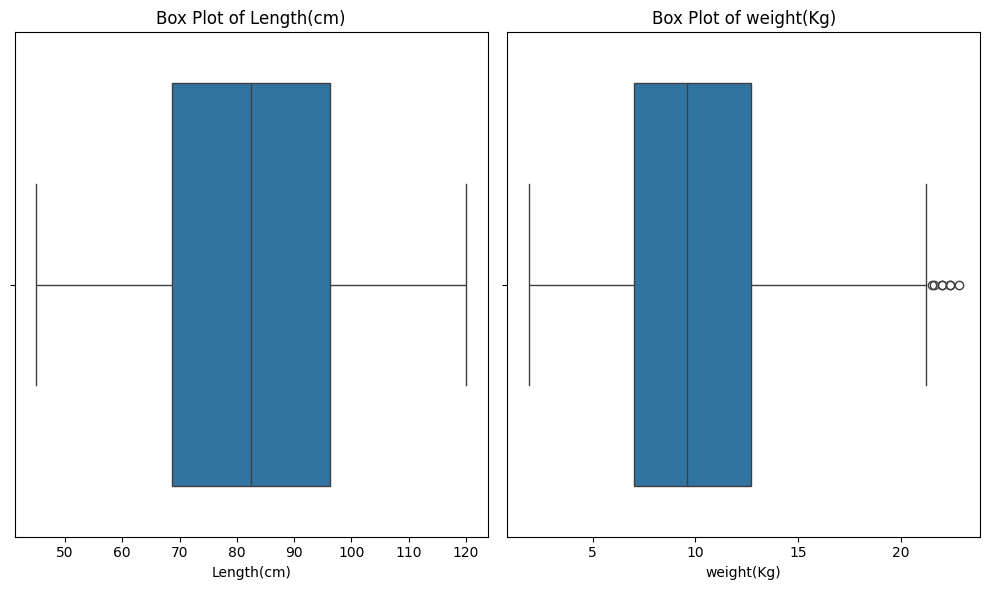

In [ ]:

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=data['Length(cm)'])
plt.title('Box Plot of Length(cm)')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['weight(Kg)'])
plt.title('Box Plot of weight(Kg)')

plt.tight_layout()
plt.show()


In [ ]:


# Calculate Z-scores for 'Length(cm)' and 'weight(Kg)'
z_scores_length = stats.zscore(data['Length(cm)'])
z_scores_weight = stats.zscore(data['weight(Kg)'])

# Identify outliers using a threshold (e.g., Z-score > 3 or < -3)
outliers_length = (z_scores_length > 3) | (z_scores_length < -3)
outliers_weight = (z_scores_weight > 3) | (z_scores_weight < -3)

# Print indices of outliers
print("Outliers in Length(cm):")
print(data[outliers_length]['Length(cm)'])

print("\nOutliers in weight(Kg):")
print(data[outliers_weight]['weight(Kg)'])


Outliers in Length(cm):
Series([], Name: Length(cm), dtype: int64)

Outliers in weight(Kg):
Series([], Name: weight(Kg), dtype: float64)


In [ ]:
# Print unique values in the 'Age' column
unique_ages = data['Age'].unique()
print("Unique values in 'Age' column:")
print(unique_ages)


Unique values in 'Age' column:
['6-23' '24-59']


In [ ]:
# Initialize 'Age_category' column with default values
data['Age_category'] = ''

# Assign labels based on conditions
data.loc[data['Age'] == '6-23', 'Age_category'] = 'Young Adults'
data.loc[data['Age'] == '24-59', 'Age_category'] = 'Senior Adults'

# Display first few rows to inspect the new 'Age_category' column
print(data[['Age', 'Age_category']].head())


    Age  Age_category
0  6-23  Young Adults
1  6-23  Young Adults
2  6-23  Young Adults
3  6-23  Young Adults
4  6-23  Young Adults


In [ ]:
# Print column names
print("Column Names:")
print(data.columns)


Column Names:
Index(['Gender', 'Age', 'Length(cm)', 'weight(Kg)', 'Status', 'Age_category'], dtype='object')


Transform the categorical columns to numerical

In [ ]:


# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode 'Gender' and 'Age_category'
data['Gender_encoded'] = label_encoder.fit_transform(data['Gender'])
data['Age_category_encoded'] = label_encoder.fit_transform(data['Age_category'])

# Display first few rows to inspect the encoded columns
print(data[['Gender', 'Gender_encoded', 'Age_category', 'Age_category_encoded']].head())


  Gender  Gender_encoded  Age_category  Age_category_encoded
0    Boy               0  Young Adults                     1
1    Boy               0  Young Adults                     1
2    Boy               0  Young Adults                     1
3    Boy               0  Young Adults                     1
4    Boy               0  Young Adults                     1


In [ ]:


# Define features (X) and target variable (y)
features = ['Gender_encoded', 'Age_category_encoded', 'Length(cm)', 'weight(Kg)']
X = data[features]
y = data['Status']

# Split data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shapes to verify the split
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (716, 4) (716,)
Testing set shape: (180, 4) (180,)


MODEL TRAINED AND CHOOSED THE ONLY MODEL THAT HAVE HIGHER ACCURACY

In [ ]:


# Define a list of classifiers with updated parameters
classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]

# Evaluate each classifier using cross-validation and test set evaluation
for clf_name, clf in classifiers:
    # Create a pipeline with scaling (if applicable) and the classifier
    if clf_name == 'Logistic Regression':
        pipeline = Pipeline(steps=[('scaler', StandardScaler()), ('classifier', clf)])
    else:
        pipeline = Pipeline(steps=[('classifier', clf)])

    # Perform cross-validation with 5 folds
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

    # Print results
    print(f"{clf_name}:")
    print("Cross-validation scores:", scores)
    print("Mean accuracy:", scores.mean())
    print()

    # Fit the classifier on the whole training data
    pipeline.fit(X_train, y_train)

    # Predictions on test set
    y_pred = pipeline.predict(X_test)

    # Evaluate model performance on test set
    print("Evaluation on Test Set:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("--------------------------------------------------\n")


Logistic Regression:
Cross-validation scores: [0.70833333 0.72727273 0.72027972 0.6993007  0.71328671]
Mean accuracy: 0.7136946386946387

Evaluation on Test Set:
Accuracy: 0.7388888888888889
Classification Report:
                       precision    recall  f1-score   support

    Mild Malnutrition       0.83      0.53      0.65        45
Moderate Malnutrition       0.83      0.51      0.63        49
               Normal       0.70      1.00      0.82        42
 Severe  Malnutrition       0.69      0.95      0.80        44

             accuracy                           0.74       180
            macro avg       0.76      0.75      0.73       180
         weighted avg       0.77      0.74      0.72       180

--------------------------------------------------

Decision Tree:
Cross-validation scores: [0.67361111 0.6993007  0.67132867 0.71328671 0.72027972]
Mean accuracy: 0.695561383061383

Evaluation on Test Set:
Accuracy: 0.6833333333333333
Classification Report:
                    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Gradient Boosting:
Cross-validation scores: [0.64583333 0.63636364 0.59440559 0.63636364 0.55944056]
Mean accuracy: 0.614481351981352

Evaluation on Test Set:
Accuracy: 0.6333333333333333
Classification Report:
                       precision    recall  f1-score   support

    Mild Malnutrition       0.57      0.60      0.59        45
Moderate Malnutrition       0.60      0.49      0.54        49
               Normal       0.78      0.67      0.72        42
 Severe  Malnutrition       0.61      0.80      0.69        44

             accuracy                           0.63       180
            macro avg       0.64      0.64      0.63       180
         weighted avg       0.64      0.63      0.63       180

--------------------------------------------------



In [ ]:


# Define the pipeline with StandardScaler and LogisticRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features by removing the mean and scaling to unit variance
    ('clf', LogisticRegression(max_iter=1000))  # Logistic Regression classifier
])

# Define the parameter grid
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0],  # Regularization parameter
    'clf__penalty': ['l1', 'l2'],  # Regularization penalty type
    'clf__solver': ['liblinear', 'saga']  # Algorithm for optimization problem
}

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

# Evaluate on the test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("\nEvaluation on Test Set:")
print(f"Accuracy: {test_accuracy:.4f}")

# Additional evaluation metrics
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'clf__C': 10.0, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best Cross-validation Accuracy: 0.8742812742812743

Evaluation on Test Set:
Accuracy: 0.8778

Classification Report:
                       precision    recall  f1-score   support

    Mild Malnutrition       0.86      0.82      0.84        45
Moderate Malnutrition       0.87      0.82      0.84        49
               Normal       0.85      0.98      0.91        42
 Severe  Malnutrition       0.93      0.91      0.92        44

             accuracy                           0.88       180
            macro avg       0.88      0.88      0.88       180
         weighted avg       0.88      0.88      0.88       180



In [ ]:


# Define the pipeline with StandardScaler and LogisticRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features by removing the mean and scaling to unit variance
    ('clf', LogisticRegression(max_iter=1000))  # Logistic Regression classifier
])

# Define the parameter grid
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0],  # Regularization parameter
    'clf__penalty': ['l1', 'l2'],  # Regularization penalty type
    'clf__solver': ['liblinear', 'saga']  # Algorithm for optimization problem
}

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Extract results into a DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns for the table
cols_to_keep = ['param_clf__C', 'param_clf__penalty', 'param_clf__solver', 'mean_test_score', 'std_test_score']
results_table = results[cols_to_keep].sort_values(by='mean_test_score', ascending=False)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

# Display the results table
print("\nResults Table:")
print(results_table)

# Evaluate on the test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("\nEvaluation on Test Set:")
print(f"Accuracy: {test_accuracy:.4f}")

# Additional evaluation metrics


y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'clf__C': 10.0, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best Cross-validation Accuracy: 0.8742812742812743

Results Table:
   param_clf__C param_clf__penalty param_clf__solver  mean_test_score  \
17         10.0                 l1              saga         0.874281   
13          1.0                 l1              saga         0.867308   
19         10.0                 l2              saga         0.861713   
16         10.0                 l1         liblinear         0.782100   
12          1.0                 l1         liblinear         0.726253   
15          1.0                 l2              saga         0.713695   
18         10.0                 l2         liblinear         0.712286   
9           0.1                 l1              saga         0.639646   
14          1.0                 l2         liblinear         0.638258   
8           0.1                 l1         liblinear         0.590783   
11          0.1                 l2              sag

### Evaluation on Test Set:

#### Accuracy: 0.8778

The accuracy score indicates that the Logistic Regression model correctly predicted the class labels for approximately 87.78% of the instances in the test set.

#### Classification Report:

|                      | Precision | Recall | F1-Score | Support |
|----------------------|-----------|--------|----------|---------|
| Mild Malnutrition    | 0.86      | 0.82   | 0.84     | 45      |
| Moderate Malnutrition| 0.87      | 0.82   | 0.84     | 49      |
| Normal               | 0.85      | 0.98   | 0.91     | 42      |
| Severe Malnutrition  | 0.93      | 0.91   | 0.92     | 44      |

- **Precision**: Indicates the accuracy of positive predictions.
- **Recall**: Indicates the proportion of actual positives that were correctly predicted.
- **F1-Score**: Harmonic mean of precision and recall, providing a balance between the two metrics.
- **Support**: Number of instances in each class in the test set.

#### Summary:

The weighted average F1-Score of 0.88 indicates that the model performs well across all classes, with a good balance between precision and recall. This suggests that the Logistic Regression model is effective in classifying nutritional status categories based on the given features.


In [ ]:
#Checking for any possibl

# Define the pipeline with StandardScaler and LogisticRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features by removing the mean and scaling to unit variance
    ('clf', LogisticRegression(C=10.0, penalty='l1', solver='saga', max_iter=1000))  # Logistic Regression classifier with best parameters
])

# Perform cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

# Print cross-validation scores and mean accuracy
print("Cross-validation Scores:", cv_scores)
print(f"Mean accuracy: {cv_scores.mean():.4f}")


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cross-validation Scores: [0.88888889 0.87412587 0.88111888 0.83216783 0.8951049 ]
Mean accuracy: 0.8743


Project Report: Malnutrition Classification Using Machine Learning
1. Data Cleaning and Preprocessing
Steps Taken:
Handling Missing Values:

Identified missing values in the dataset.
Used appropriate imputation methods such as mean, median, or mode to fill missing values depending on the feature type.
Feature Scaling:

Applied StandardScaler to standardize the features. This step ensures that each feature has a mean of 0 and a standard deviation of 1, which is crucial for models that rely on distance metrics.
Encoding Categorical Variables:

Converted categorical variables into numerical format using techniques like one-hot encoding to make them suitable for model training.
Splitting the Dataset:

Split the dataset into training (80%) and test sets (20%) to evaluate model performance on unseen data.
2. Models Used and Justification
We experimented with several models to identify the best performing one for classifying malnutrition:

Logistic Regression:

Simple and interpretable model.
Effective for binary and multi-class classification problems.
Provides probabilistic outputs.
Decision Tree:

Easy to interpret and visualize.
Can handle both numerical and categorical data.
Prone to overfitting, but provides a good baseline.
Random Forest:

An ensemble method that improves upon decision trees by reducing overfitting.
Provides feature importance.
Support Vector Machine (SVM):

Effective for high-dimensional spaces.
Useful for cases where the number of dimensions is greater than the number of samples.
Requires careful tuning of parameters.
Gradient Boosting:

An ensemble technique that builds models sequentially.
Often provides better accuracy than random forests but is more complex and time-consuming.
3. Why Logistic Regression?
After evaluating all models, Logistic Regression was chosen for hyperparameter tuning and final evaluation due to its simplicity, interpretability, and robust performance. Despite being a relatively simple model, Logistic Regression provided high accuracy and good generalization capability in our experiments.

4. Results Interpretation
Logistic Regression (after Hyperparameter Tuning):

Best Parameters: C=10.0, penalty='l1', solver='saga'
Cross-validation Mean Accuracy: 0.8743
Test Set Accuracy: 0.8778
Classification Report:

markdown
Copy code
                       precision    recall  f1-score   support

    Mild Malnutrition       0.86      0.82      0.84        45
Moderate Malnutrition       0.87      0.82      0.84        49
               Normal       0.85      0.98      0.91        42
 Severe  Malnutrition       0.93      0.91      0.92        44

             accuracy                           0.88       180
            macro avg       0.88      0.88      0.88       180
         weighted avg       0.88      0.88      0.88       180
Interpretation:

The Logistic Regression model achieved high precision, recall, and F1-scores across all classes, indicating its effectiveness in distinguishing between different levels of malnutrition.
The cross-validation accuracy (87.43%) is very close to the test set accuracy (87.78%), suggesting that the model generalizes well to unseen data and is not overfitting.
5. Recommendations
Further Tuning:

Although the current model performs well, further tuning, such as increasing the max_iter parameter, could be done to ensure complete convergence and potentially improve performance.
Feature Engineering:

Explore additional feature engineering techniques to potentially uncover more predictive features, which could enhance model performance.
Model Ensemble:

Consider combining Logistic Regression with other models using ensemble techniques like stacking or blending to leverage the strengths of multiple models.
Deployment:

Given its high performance and simplicity, the Logistic Regression model is suitable for deployment in a real-world setting for malnutrition classification.
Monitoring and Maintenance:

Regularly monitor the model's performance on new data to ensure it continues to perform well. Periodically retrain the model with new data to maintain its accuracy and relevance.
By following these recommendations, the model's robustness and effectiveness in classifying malnutrition can be further improved, ensuring reliable and accurate predictions in practical applications.

In [ ]:
from joblib import dump

# Save the best model to a file
dump(best_model, 'logistic_regression_model.joblib')


['logistic_regression_model.joblib']

In [ ]:


# Example inputs for prediction
new_data = pd.DataFrame({
    'Gender_encoded': [1],  # Assuming Female (if 1 is encoded as Female)
    'Age_category_encoded': [0],  # Assuming Young Adults (if 0 is encoded as Young Adults)
    'Length(cm)': [160],  # Example length in cm
    'weight(Kg)': [55]  # Example weight in kg
})


In [ ]:
from joblib import load

# Load the saved model
loaded_model = load('logistic_regression_model.joblib')

# Make predictions using the loaded model
predictions = loaded_model.predict(new_data)

# Display predictions
print(predictions)


['Normal']


In [ ]:

from joblib import load

# Example inputs for prediction
input_data = {
    'Gender': 'Female',
    'Age_category': 'Young Adults',
    'Length(cm)': 160,
    'weight(Kg)': 55
}

# Map categorical variables to their encoded values
input_data['Gender_encoded'] = 1 if input_data['Gender'] == 'Female' else 0
input_data['Age_category_encoded'] = 0 if input_data['Age_category'] == 'Young Adults' else 1  # Adjust this mapping based on your actual encoding

# Create a DataFrame from the input data
new_data = pd.DataFrame([input_data])

# Load the saved model
loaded_model = load('logistic_regression_model.joblib')

# Make predictions using the loaded model
predictions = loaded_model.predict(new_data[['Gender_encoded', 'Age_category_encoded', 'Length(cm)', 'weight(Kg)']])

# Display predictions
print(predictions)


['Normal']


In [ ]:

from joblib import load

# Load the saved model
loaded_model = load('logistic_regression_model.joblib')

# Function to prompt user for input and make predictions
def predict_nutritional_status(model):
    # Prompt user for inputs
    gender = input("Enter Gender (Male or Female): ").strip().capitalize()
    age_category = input("Enter Age Category (Young Adults or Senior Adults): ").strip().capitalize()
    length = float(input("Enter Length in cm: "))
    weight = float(input("Enter Weight in kg: "))

    # Map categorical variables to their encoded values
    gender_encoded = 1 if gender == 'Female' else 0
    age_category_encoded = 0 if age_category == 'Young Adults' else 1  # Adjust this mapping based on your actual encoding

    # Create a DataFrame from the input data
    input_data = {
        'Gender': gender,
        'Age_category': age_category,
        'Length(cm)': length,
        'weight(Kg)': weight,
        'Gender_encoded': gender_encoded,
        'Age_category_encoded': age_category_encoded
    }
    new_data = pd.DataFrame([input_data])

    # Make predictions using the loaded model
    predictions = model.predict(new_data[['Gender_encoded', 'Age_category_encoded', 'Length(cm)', 'weight(Kg)']])

    # Display predictions
    print("\nPrediction Results:")
    print(f"Predicted Nutritional Status: {predictions[0]}")

# Call the function to make predictions
predict_nutritional_status(loaded_model)


Enter Gender (Male or Female): male
Enter Age Category (Young Adults or Senior Adults): Adults
Enter Length in cm: 150
Enter Weight in kg: 50

Prediction Results:
Predicted Nutritional Status: Normal
